<a href="https://colab.research.google.com/github/kowsik005/All_ML_models/blob/main/DBSCAN_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (500, 2)

First 5 rows:
   Feature_1  Feature_2
0   0.830640  -0.425055
1   0.759684   0.829335
2   1.039113  -0.488126
3  -0.281591   0.969380
4   0.315699   1.111454

Scaled data:
[[ 0.37087295 -1.34521023]
 [ 0.28949692  1.14654156]
 [ 0.60996153 -1.47049622]
 [-0.90469728  1.42473215]
 [-0.21969017  1.7069507 ]]

Clustered Data:
    Feature_1  Feature_2  Cluster
0    0.830640  -0.425055        0
1    0.759684   0.829335        1
2    1.039113  -0.488126        0
3   -0.281591   0.969380        1
4    0.315699   1.111454        1
5    1.261713  -0.491564        0
6    1.067240  -0.408603        0
7    0.046423   1.084831        1
8    0.600475   0.687053        1
9    1.771305  -0.180980        0
10   1.002384   0.078906        1
11  -0.670324   0.536262        1
12   1.511444  -0.500555        0
13   0.389976   0.806293        1
14   1.111958  -0.502232        0
15   1.211860  -0.500241        0
16   1.991521   0.409084        0
17   0.933278   0.409100        1
18  

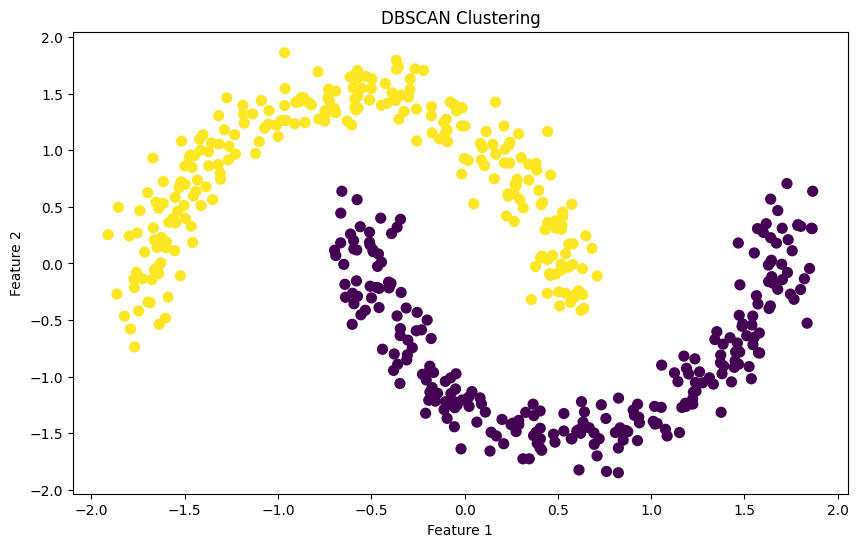


Silhouette Score: 0.3836


In [1]:
# ==========================================================
# DBSCAN CLUSTERING - COMPLETE EXAMPLE
# ==========================================================

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# ==========================================================
# 2. Create sample dataset
# ==========================================================

X, y = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

print("Dataset shape:", X.shape)


# ==========================================================
# 3. Convert to DataFrame
# ==========================================================

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

print("\nFirst 5 rows:")
print(df.head())


# ==========================================================
# 4. Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled data:")
print(X_scaled[:5])


# ==========================================================
# 5. Create DBSCAN Model
# ==========================================================

dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)


# ==========================================================
# 6. Fit DBSCAN
# ==========================================================

cluster_labels = dbscan.fit_predict(X_scaled)

df["Cluster"] = cluster_labels


# ==========================================================
# 7. Display Cluster Labels
# ==========================================================

print("\nClustered Data:")
print(df.head(20))


# ==========================================================
# 8. Count points in each cluster
# ==========================================================

print("\nCluster Distribution:")

print(
    df["Cluster"].value_counts().sort_index()
)


# ==========================================================
# 9. Identify Noise / Outliers
# ==========================================================

noise_points = np.sum(cluster_labels == -1)

print("\nNumber of Noise Points:", noise_points)


# ==========================================================
# 10. Number of Clusters
# ==========================================================

unique_clusters = set(cluster_labels)

number_of_clusters = len(
    unique_clusters - {-1}
)

print(
    "Number of Clusters:",
    number_of_clusters
)


# ==========================================================
# 11. Visualize DBSCAN Clusters
# ==========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=cluster_labels,
    s=50
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()


# ==========================================================
# 12. Silhouette Score
# ==========================================================

# Calculate only if there is more than one cluster
# and not all points are noise.

non_noise = cluster_labels != -1

if (
    number_of_clusters > 1
    and np.sum(non_noise) > number_of_clusters
):

    score = silhouette_score(
        X_scaled[non_noise],
        cluster_labels[non_noise]
    )

    print(
        "\nSilhouette Score:",
        round(score, 4)
    )

else:

    print(
        "\nSilhouette Score cannot be calculated."
    )